# News alerts - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00.** You drive a coding agent (Codex, Claude Code, or
Antigravity CLI). Paste each prompt, run the code, apply the check.


## About this data source

Four ways the world learns about an outbreak *before the data exists*, in order of how
easily we can use them:

- **GDELT** indexes world news in 100+ languages and gives it away through a free API with
  **no key**, which is why it is the one we scrape in class.
  **Explore:** <https://www.gdeltproject.org/>
- **HealthMap** reads news and official reports automatically and pins them on a world map.
  **Explore:** <https://www.healthmap.org/>
- **ProMED** is the opposite: real human experts posting curated outbreak reports since 1994.
  It flagged COVID about a day before the official notice. **Explore:**
  <https://promedmail.org/>
- **Media Cloud** is the scholars' media-analysis tool: **200M+ stories** in curated
  *collections* (national presses, country sets), built for studying *how* a topic is
  covered. Needs a **free API key**, so here it is a bonus rather than the main path.
  **Explore:** <https://search.mediacloud.org/>

> Open HealthMap and zoom to a region (every dot is a report), then read one ProMED post, to
> feel the difference between an automated map and a curated expert alert. Media Cloud shows
> you a third thing: attention over time, by outlet.

**The trade-off worth naming:** GDELT is *breadth with no key*; Media Cloud is *curation
with a key*. That is the same pattern as OpenSky vs OpenFlights, and Facebook posts vs the
Facebook symptom survey.


## Step 1: scan the news

> *Using the GDELT DOC 2.0 API (free, no key), find news articles from the past month*
> *that mention dengue outbreaks. Return a tidy table with date, source country, domain,*
> *headline and URL, and report how many articles and the date range.*


In [1]:
# Agent's GDELT scan:
import os, json
import urllib.request, urllib.parse
import pandas as pd, matplotlib.pyplot as plt

UA = {"User-Agent": "SISMID2026-course/1.0 (your-email@example.com)"}


def cache_path(fname):
    for p in (f"../data/{fname}", f"data/{fname}", f"./{fname}"):
        if os.path.exists(p):
            return p
    return None


def fetch(url, timeout=120):
    return urllib.request.urlopen(urllib.request.Request(url, headers=UA), timeout=timeout).read()


# ===== EDIT for your own disease / region =====
MY_QUERY = "dengue outbreak"
TIMESPAN = "1m"  # 1m = past month; also 1w, 3m ...
# =============================================


def gdelt_scan(query=MY_QUERY, timespan=TIMESPAN, maxrecords=250):
    """News articles matching `query` from the past `timespan`, via GDELT DOC 2.0
    (free, no key). Tidy columns: date, sourcecountry, domain, title, url.
    Falls back to the cache on any failure."""
    api = ("https://api.gdeltproject.org/api/v2/doc/doc"
          f"?query={urllib.parse.quote(query)}&mode=artlist&maxrecords={maxrecords}"
          f"&format=json&timespan={timespan}")
    try:
        arts = json.loads(fetch(api)).get("articles", [])
        news = pd.DataFrame([{"seendate": a.get("seendate", ""),
                              "sourcecountry": a.get("sourcecountry", ""),
                              "domain": a.get("domain", ""),
                              "title": (a.get("title") or "").strip(),
                              "url": a.get("url", "")} for a in arts])
        if news.empty:
            raise RuntimeError("no articles returned (rate-limited?)")
    except Exception as e:
        print(f"Live GDELT pull failed ({type(e).__name__}): {e}")
        p = cache_path("gdelt_dengue_articles.csv")
        print("Using cached snapshot:", p)
        news = pd.read_csv(p)
    news["date"] = pd.to_datetime(news["seendate"], format="%Y%m%dT%H%M%SZ", errors="coerce")
    return news


news = gdelt_scan()
print(f"{len(news)} articles, {news['date'].min()} to {news['date'].max()}")
news[["date", "sourcecountry", "domain", "title", "url"]].head(8)


245 articles, 2026-06-21 20:00:00 to 2026-07-21 18:00:00


,date,sourcecountry,domain,title,url
0,2026-06-23 14:30:00,India,thehindu.com,Sri Lanka to appoint military - led dengue mon...,https://www.thehindu.com/news/international/sr...
1,2026-06-24 05:00:00,India,thehindu.com,Why is Sri Lanka dengue outbreak straining its...,https://www.thehindu.com/news/international/wh...
2,2026-07-16 09:15:00,Sri Lanka,dailymirror.lk,Sri Lanka dengue battle at a crossroads - Brea...,https://www.dailymirror.lk/breaking-news/Sri-L...
3,2026-07-18 12:15:00,Sri Lanka,dailymirror.lk,"Dengue deaths in 2026 top 50 , surpassing 2025...",https://www.dailymirror.lk/breaking-news/Dengu...
4,2026-07-21 08:45:00,Malaysia,utusan.com.my,Sri Lanka guna dron tentera tangani wabak denggi,https://www.utusan.com.my/terkini/2026/07/sri-...
5,2026-06-27 04:00:00,Sri Lanka,dailymirror.lk,Sri Lanka Dengue outbreak reaches epidemic lev...,https://www.dailymirror.lk/breaking-news/Sri-L...
6,2026-07-06 12:45:00,United States,borgenproject.org,Diseases Impacting Bolivia and the Work To Mit...,https://borgenproject.org/diseases-impacting-b...
7,2026-07-15 02:45:00,Sri Lanka,ft.lk,Road drains driving dengue : Study reveals 70 ...,https://www.ft.lk/columns/Road-drains-driving-...


## Step 2: emerging-outbreak watch

> *Tally the articles by source country and plot the top 12, then plot article volume*
> *per day. Summarise which countries are newly reporting activity.*

**Your check:** is a spike a real outbreak, or one wire story syndicated everywhere?


In [2]:
# Agent's country tally + volume plot:


## Step 3: sanity-check and save

> *Report article count, unique domains, and how many duplicate headlines there are*
> *(syndication). Save a tidy CSV and print the five most recent headlines.*


In [3]:
# Agent's checks + save:


## Bonus: Media Cloud (needs a free API key)

> *Media Cloud indexes 200M+ news stories in curated collections and has a Python client*
> *(`pip install mediacloud`). Using mediacloud.api.SearchApi with my MEDIACLOUD_API_KEY*
> *environment variable, pull stories from the last 30 days matching my query in the US*
> *national collection (id 34412234), and show publish date, outlet and headline. If the key*
> *is not set, skip cleanly and tell me GDELT already covered it.*

Get a free key by signing up at <https://search.mediacloud.org/>. Compare what Media Cloud
returns against GDELT: curated collections versus raw breadth.


In [4]:
# Agent's Media Cloud pull (optional, needs MEDIACLOUD_API_KEY):
import os
from datetime import date, timedelta

MC_KEY = os.environ.get("MEDIACLOUD_API_KEY")
US_NATIONAL_COLLECTION = 34412234  # collection ids are listed in the Media Cloud directory

if MC_KEY:
    import mediacloud.api

    mc = mediacloud.api.SearchApi(MC_KEY)
    end = date.today()
    start = end - timedelta(days=30)
    stories, _token = mc.story_list("dengue", start_date=start, end_date=end,
                                     collection_ids=[US_NATIONAL_COLLECTION])
    mc_df = pd.DataFrame(stories)
    print(f'Media Cloud: {len(mc_df)} stories (page 1) for "dengue" in the last 30 days, US national collection')
    if not mc_df.empty:
        cols = [c for c in ["publish_date", "media_name", "title"] if c in mc_df.columns]
        display(mc_df[cols].head(8))
else:
    print("MEDIACLOUD_API_KEY not set -> skipping Media Cloud.")
    print("Free key: sign up at https://search.mediacloud.org/")
    print("The GDELT results above are the no-key path and need nothing extra.")


Media Cloud: 86 stories (page 1) for "dengue" in the last 30 days, US national collection


,publish_date,media_name,title
0,2026-07-21,theguardian.com,Google wants to release 32 million sterile mos...
1,2026-07-20,usnews.com,Sri Lanka Uses Air Force Drones to Tackle Spre...
2,2026-07-20,theconversation.com,Google wants to release 16 million sterile moz...
3,2026-07-19,arstechnica.com,"As mosquito ranges expand, better monitoring i..."
4,2026-07-19,theweek.com,Why Cuba is under siege
5,2026-07-18,theconversation.com,"Dengue, Zika, chikungunya"
6,2026-07-18,techradar.com,This autonomous drone eradicates mosquitoes — ...
7,2026-07-17,gazettenet.com,Aging with Adventure with Eric Weld: Is the go...


3855 days -> 552 weeks, 2016-01-03 to 2026-07-26


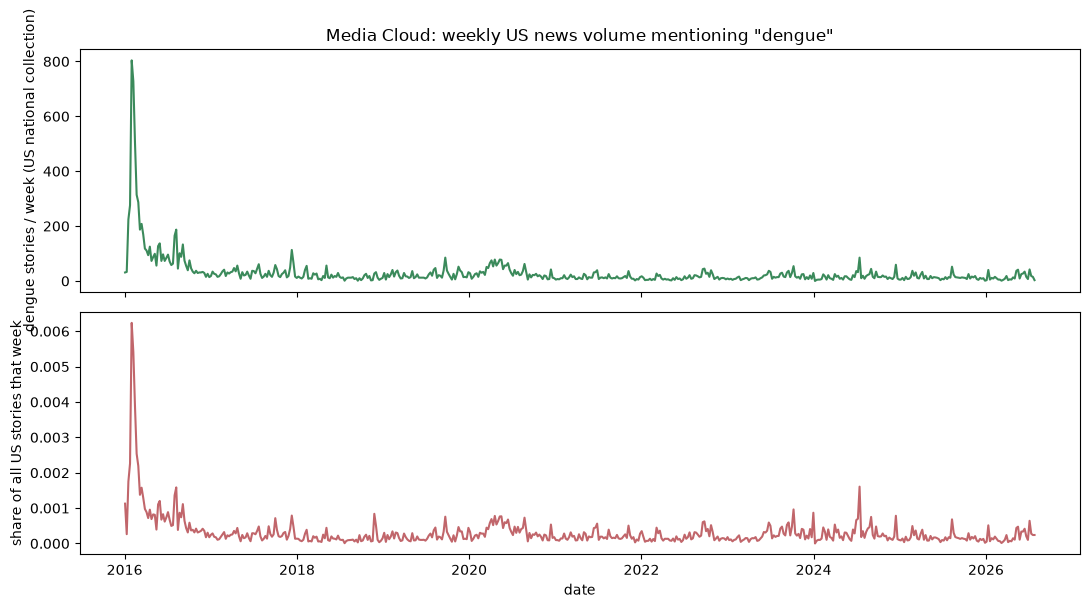

In [5]:
# Agent's Media Cloud weekly dengue-news-volume series (to discount Google Trends spikes):
# Idea: a Google Trends spike for "dengue" could reflect real local incidence, OR just a
# wave of media coverage driving searches with no local cases at all. A weekly count of
# US dengue news volume lets us tell those apart: if Trends spikes without a matching
# news-volume spike, that's a stronger signal of real search-driven local concern; if both
# spike together, the Trends spike is more likely media-driven.

if MC_KEY:
    counts = mc.story_count_over_time("dengue", start_date=date(2016, 1, 1), end_date=date.today(),
                                       collection_ids=[US_NATIONAL_COLLECTION])
    daily = pd.DataFrame(counts)  # columns: date, count, total_count, ratio
    daily["date"] = pd.to_datetime(daily["date"])

    weekly = (daily.set_index("date")[["count", "total_count"]]
                   .resample("W").sum().reset_index())
    weekly["ratio"] = weekly["count"] / weekly["total_count"]

    print(f"{len(daily)} days -> {len(weekly)} weeks, {weekly['date'].min().date()} to {weekly['date'].max().date()}")
    weekly.to_csv("../data/mediacloud_dengue_us_weekly.csv", index=False)

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    axes[0].plot(weekly["date"], weekly["count"], color="#3B8A5B")
    axes[0].set_ylabel("dengue stories / week (US national collection)")
    axes[0].set_title("Media Cloud: weekly US news volume mentioning \"dengue\"")
    axes[1].plot(weekly["date"], weekly["ratio"], color="#C1666B")
    axes[1].set_ylabel("share of all US stories that week")
    axes[1].set_xlabel("date")
    plt.tight_layout()
    plt.savefig("../mediacloud_dengue_us_weekly.png", dpi=150)
    plt.show()
else:
    print("MEDIACLOUD_API_KEY not set -> skipping the Media Cloud weekly volume series.")


In [6]:
# get the healthmap data for dengue related outbreak in the past 2 years

## Reflection

- News catches what has no data stream yet; it needs a human read.
- **Stretch:** swap in your own disease and region, and try `TIMESPAN='1w'`.
